In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.dates as mdates
from matplotlib.colors import ListedColormap, BoundaryNorm
from shapely.geometry import Point
from scipy.stats import gamma,norm,fisk,wilcoxon
from sklearn.cluster import KMeans
import re
import sys
from pathlib import Path
import logging
from glob import glob

# Add project root to path
project_root = Path.cwd().parent.parent
sys.path.append(str(project_root))

In [2]:
# Configuration
config = {
    'input_data_bow': project_root / 'data' / 'input_data' / 'for_report' / 'bow',
    'input_data_oldman': project_root / 'data' / 'input_data' / 'for_report' / 'oldman',
    'gap_filled_bow_canswe_data' : project_root / 'data' / 'output_data' / 'for_paper'/'FROSTBITE' /'bow_swe_gapfilled_data_final.nc',
    'gap_filled_oldman_canswe_data' : project_root / 'data' / 'output_data' / 'for_report'/'oldman' /'oldman_swe_gapfilled_data_final.nc',
    'shapefile': project_root / 'data' / 'input_data' / 'shapefiles'/'BowRiverBasin'/'Bow_elevation_combined.shp',
    'output_plots': project_root / 'data' / 'output_data' / 'for_report'}

# Data preparation

1. Create historic SWE dataset (Gap-filled CANSWE data for each basin).  

In [3]:
# open canswe data
bow_canswe_gapfilled_ds = xr.open_dataset(config['gap_filled_bow_canswe_data'])

oldman_canswe_gapfilled_ds = xr.open_dataset(config['gap_filled_oldman_canswe_data'])

# convert to dataframe and display
bow_canswe_gapfilled_df = bow_canswe_gapfilled_ds.to_dataframe()
bow_canswe_gapfilled_df.reset_index(inplace=True)
display(bow_canswe_gapfilled_df.head())

oldman_canswe_gapfilled_df = oldman_canswe_gapfilled_ds.to_dataframe()
oldman_canswe_gapfilled_df.reset_index(inplace=True)    
display(oldman_canswe_gapfilled_df.head())

,time,station_id,lat,lon,station_name,SWE
0,1980-01-01,ALE-05BA801,51.423084,-116.183693,BOW RIVER,NaN
1,1980-01-01,ALE-05BA802,51.437962,-116.181274,PIPESTONE UPPER,NaN
2,1980-01-01,ALE-05BA806,51.416618,-116.238274,MIRROR LAKE,NaN
3,1980-01-01,ALE-05BA808,51.424427,-116.213310,CHATEAU LAWN,NaN
4,1980-01-01,ALE-05BA810,51.474091,-116.102745,PTARMIGAN HUT,NaN


,time,station_id,lat,lon,station_name,SWE
0,1980-01-01,ALE-05AA801,49.279552,-114.372910,WEST CASTLE BUSH,NaN
1,1980-01-01,ALE-05AA803,49.745266,-114.612213,ALLISON PASS,NaN
2,1980-01-01,ALE-05AA805,49.266666,-114.349998,WEST CASTLE SNOW,NaN
3,1980-01-01,ALE-05AA806,49.816666,-114.633331,RACE HORSE CREEK,NaN
4,1980-01-01,ALE-05AA809,49.359940,-114.518234,GARDINER H.W.,NaN


2. Get latest data for the season from the downloaded data 

In [4]:
def extract_station_id(filepath):
    """
    Extract station id from filenames like:
    05BB803_SW_C.Corrected-Seasonal.csv
    """
    fname = Path(filepath).name
    m = re.search(r'([0-9A-Za-z]+)_', fname)
    return m.group(1) if m else fname


def find_data_start(filepath):
    """
    Find the row number right after the '#Timestamp;Value' line.
    """
    with open(filepath, 'r', encoding='utf-8-sig', errors='ignore') as f:
        for i, line in enumerate(f):
            if line.strip().startswith('#Timestamp;Value'):
                return i + 1
    raise ValueError(f"Could not find '#Timestamp;Value' header in {filepath}")


def read_alberta_timeseries(filepath, value_name='SWE'):
    """
    Read one Alberta seasonal CSV file.

    Returns columns:
    station_id, time, SWE
    """
    station_id = extract_station_id(filepath)
    skiprows = find_data_start(filepath)

    df = pd.read_csv(
        filepath,
        sep=';',
        skiprows=skiprows,
        names=['Timestamp', 'Value'],
        encoding='utf-8-sig'
    )

    df['time'] = pd.to_datetime(df['Timestamp'], errors='coerce')
    df[value_name] = pd.to_numeric(df['Value'], errors='coerce')

    df = df.dropna(subset=['time']).copy()
    df['station_id'] = station_id

    return df[['station_id', 'time', value_name]]


def add_season_year_nov_may(df, time_col='time'):
    """
    Keep only Nov-May data and assign season_year.

    Example:
    Nov-Dec 1984 -> season_year 1984
    Jan-May 1985 -> season_year 1984
    """
    out = df.copy()
    out[time_col] = pd.to_datetime(out[time_col], errors='coerce')

    out = out.dropna(subset=[time_col]).copy()
    out['month'] = out[time_col].dt.month
    out['year'] = out[time_col].dt.year

    # Keep only Nov-May
    out = out[out['month'].isin([10,11, 12, 1, 2, 3, 4, 5])].copy()

    out['season_year'] = out['year']
    out.loc[out['month'].isin([1, 2, 3, 4, 5]), 'season_year'] = (
        out.loc[out['month'].isin([1, 2, 3, 4, 5]), 'year'] - 1
    )

    out = out.drop(columns=['month', 'year'])

    return out


def read_all_alberta_csvs(folderpath, value_name='SWE'):
    """
    Read all CSV files in a folder and combine them.

    Returns columns:
    station_id, time, SWE
    """
    folder = Path(folderpath)
    csv_files = sorted(folder.glob('*.csv'))

    if not csv_files:
        raise FileNotFoundError(f"No CSV files found in {folder}")

    all_dfs = []
    for file in csv_files:
        try:
            df = read_alberta_timeseries(file, value_name=value_name)
            all_dfs.append(df)
            print(f"Read: {file.name} -> {len(df)} rows")
        except Exception as e:
            print(f"Skipped {file.name}: {e}")

    if not all_dfs:
        raise ValueError("No valid CSV files were read.")

    combined = pd.concat(all_dfs, ignore_index=True)
    combined = combined.sort_values(['station_id', 'time']).reset_index(drop=True)

    return combined


def build_swe_table(folderpath):
    """
    Full pipeline:
    1. Read all CSVs in folder
    2. Add season_year
    3. Return final table with columns:
       station_id, time, SWE, season_year
    """
    df = read_all_alberta_csvs(folderpath, value_name='SWE')
    df = add_season_year_nov_may(df, time_col='time')

    df = df[['station_id', 'time', 'SWE', 'season_year']].copy()
    df = df.sort_values(['station_id', 'time']).reset_index(drop=True)

    return df

def daily_aggregate(df, value_col='SWE', how='last'):
    """
    Aggregate to daily data by station.
    For SWE, 'last' is usually the best choice.
    """
    if how == 'sum':
        out = (
            df.set_index('time')
              .groupby('station_id')[value_col]
              .resample('D')
              .sum()
              .reset_index()
        )
    elif how == 'mean':
        out = (
            df.set_index('time')
              .groupby('station_id')[value_col]
              .resample('D')
              .mean()
              .reset_index()
        )
    elif how == 'last':
        out = (
            df.set_index('time')
              .groupby('station_id')[value_col]
              .resample('D')
              .last()
              .reset_index()
        )
    else:
        raise ValueError("how must be 'sum', 'mean', or 'last'")


In [5]:
# Open CSVs, keep last SWE value per day, and create daily tables

# Bow basin
bow_raw = build_swe_table(config['input_data_bow'])
bow_swe_table = (
    bow_raw.sort_values(['station_id', 'season_year', 'time'])
           .set_index('time')
           .groupby(['station_id', 'season_year'])['SWE']
           .resample('D')
           .last()
           .reset_index()
)

# Oldman basin
oldman_raw = build_swe_table(config['input_data_oldman'])
oldman_swe_table = (
    oldman_raw.sort_values(['station_id', 'season_year', 'time'])
              .set_index('time')
              .groupby(['station_id', 'season_year'])['SWE']
              .resample('D')
              .last()
              .reset_index()
)

# keep only 2025 season year
#bow_swe_table = bow_swe_table[bow_swe_table['season_year'] == 2025].copy()
#oldman_swe_table = oldman_swe_table[oldman_swe_table['season_year'] == 2025].copy()

display(bow_raw.head())
display(oldman_raw.head())
display(bow_swe_table.head())
display(oldman_swe_table.head())
#display(daily_table.head())

Read: 05BB803_SW_C.Corrected-Seasonal.csv -> 355129 rows
Read: 05BF824_SW_C.Corrected-Seasonal.csv -> 339487 rows
Read: 05BJ805_SW_C.Corrected-Seasonal.csv -> 323828 rows
Read: 05BL811_SW_C.Corrected-Seasonal.csv -> 282719 rows
Read: 05BL812_SW_C.Corrected-Seasonal.csv -> 333428 rows
Read: 05CA805_SW_C.Corrected-Seasonal.csv -> 251112 rows
Read: 05AA809_SW_C.Corrected-Seasonal.csv -> 290591 rows
Read: 05AA817_SW_C.Corrected-Seasonal.csv -> 255260 rows
Read: 05AD803_SW_C.Corrected-Seasonal.csv -> 62356 rows


,station_id,time,SWE,season_year
0,05BB803,1984-03-12 10:00:00,472.0,1983
1,05BB803,1984-03-12 11:00:00,472.0,1983
2,05BB803,1984-03-12 12:00:00,472.0,1983
3,05BB803,1984-03-12 13:00:00,472.0,1983
4,05BB803,1984-03-12 14:00:00,472.0,1983


,station_id,time,SWE,season_year
0,05AA809,1984-04-01 00:00:00,427.0,1983
1,05AA809,1984-04-01 01:00:00,427.0,1983
2,05AA809,1984-04-01 02:00:00,428.0,1983
3,05AA809,1984-04-01 03:00:00,428.0,1983
4,05AA809,1984-04-01 04:00:00,428.0,1983


,station_id,season_year,time,SWE
0,05BB803,1983,1984-03-12,473.0
1,05BB803,1983,1984-03-13,485.0
2,05BB803,1983,1984-03-14,492.0
3,05BB803,1983,1984-03-15,492.0
4,05BB803,1983,1984-03-16,492.0


,station_id,season_year,time,SWE
0,05AA809,1983,1984-04-01,428.0
1,05AA809,1983,1984-04-02,429.0
2,05AA809,1983,1984-04-03,429.0
3,05AA809,1983,1984-04-04,430.0
4,05AA809,1983,1984-04-05,443.0


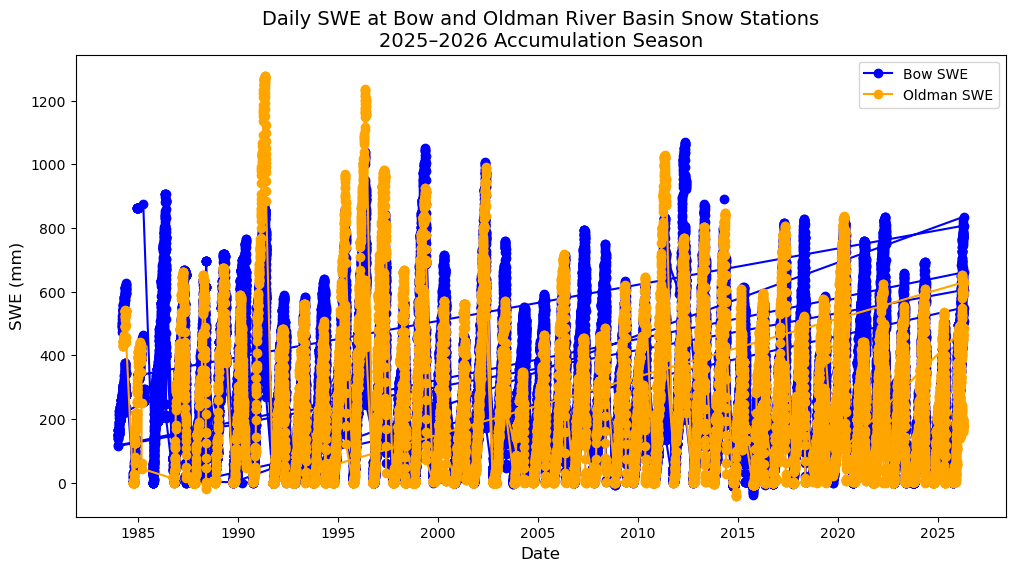

In [6]:
# plot bow_swe_table
fig, ax = plt.subplots(figsize=(12,6))
plt.plot(bow_swe_table['time'], bow_swe_table['SWE'], marker='o', linestyle='-', color='blue', label='Bow SWE')
plt.plot(oldman_swe_table['time'], oldman_swe_table['SWE'], marker='o', linestyle='-', color='orange', label='Oldman SWE')
ax.set_title('Daily SWE at Bow and Oldman River Basin Snow Stations\n2025–2026 Accumulation Season', fontsize=14)
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('SWE (mm)', fontsize=12)
ax.legend()
plt.show()

3. Extract monitoring stations historic data 

In [7]:
def extract_historic_by_station_ids(
    historic_df,
    current_df,
    historic_id_col="station_id",
    current_id_col="station_id",
):
    """
    Extract historic rows for stations present in current_df.
    Handles exact matches and prefixed historic IDs (e.g., ALE-05BB803 -> 05BB803).
    """
    target_ids = current_df[current_id_col].dropna().astype(str).unique().tolist()
    target_set = set(target_ids)

    historic_unique_ids = historic_df[historic_id_col].dropna().astype(str).unique().tolist()

    # Map historic station IDs to current station IDs
    id_map = {}
    for hid in historic_unique_ids:
        if hid in target_set:
            id_map[hid] = hid
            continue

        matches = [tid for tid in target_ids if hid.endswith(tid)]
        if len(matches) == 1:
            id_map[hid] = matches[0]

    # Filter and add matched station id
    out = historic_df[historic_df[historic_id_col].astype(str).isin(id_map.keys())].copy()
    out["source_station_id"] = out[historic_id_col].astype(str)
    out[current_id_col] = out["source_station_id"].map(id_map)

    out = out.sort_values([current_id_col, "time"]).reset_index(drop=True)
    return out



# Extract historic data corresponding to station IDs in latest-season tables
bow_historic_matched = extract_historic_by_station_ids(
    historic_df=bow_canswe_gapfilled_df,
    current_df=bow_swe_table,
)

# add season_year to historic matched data
bow_historic_matched = add_season_year_nov_may(bow_historic_matched, time_col='time')
#drop 1979 season year from historic matched data
bow_historic_matched = bow_historic_matched[bow_historic_matched['season_year'] != 1979].copy()

oldman_historic_matched = extract_historic_by_station_ids(
    historic_df=oldman_canswe_gapfilled_df,
    current_df=oldman_swe_table,
)
oldman_historic_matched = add_season_year_nov_may(oldman_historic_matched, time_col='time')
#drop 1979 season year from historic matched data
oldman_historic_matched = oldman_historic_matched[oldman_historic_matched['season_year'] != 1979].copy()


display(bow_historic_matched.head())
display(oldman_historic_matched.head())
print("Bow rows:", len(bow_historic_matched))
print("Oldman rows:", len(oldman_historic_matched))

,time,station_id,lat,lon,station_name,SWE,source_station_id,season_year
274,1980-10-01,05BB803,51.079578,-115.777596,SUNSHINE VILLAGE,NaN,ALE-05BB803,1980
275,1980-10-02,05BB803,51.079578,-115.777596,SUNSHINE VILLAGE,NaN,ALE-05BB803,1980
276,1980-10-03,05BB803,51.079578,-115.777596,SUNSHINE VILLAGE,NaN,ALE-05BB803,1980
277,1980-10-04,05BB803,51.079578,-115.777596,SUNSHINE VILLAGE,NaN,ALE-05BB803,1980
278,1980-10-05,05BB803,51.079578,-115.777596,SUNSHINE VILLAGE,NaN,ALE-05BB803,1980


,time,station_id,lat,lon,station_name,SWE,source_station_id,season_year
274,1980-10-01,05AA809,49.35994,-114.518234,GARDINER H.W.,NaN,ALE-05AA809,1980
275,1980-10-02,05AA809,49.35994,-114.518234,GARDINER H.W.,NaN,ALE-05AA809,1980
276,1980-10-03,05AA809,49.35994,-114.518234,GARDINER H.W.,NaN,ALE-05AA809,1980
277,1980-10-04,05AA809,49.35994,-114.518234,GARDINER H.W.,NaN,ALE-05AA809,1980
278,1980-10-05,05AA809,49.35994,-114.518234,GARDINER H.W.,NaN,ALE-05AA809,1980


Bow rows: 64218
Oldman rows: 32109


In [8]:
# check if nan in station_name_original
print("Unique Bow station_name_gapfilled values:")
print(bow_historic_matched['station_name'].unique())

print("Unique Oldman station_name_gapfilled values:")
print(oldman_historic_matched['station_name'].unique())


Unique Bow station_name_gapfilled values:
['SUNSHINE VILLAGE' 'THREE ISLE LAKE' 'LITTLE ELBOW' 'LOST CREEK'
 'MOUNT ODLUM III' 'SKOKI MOUNTAIN']
Unique Oldman station_name_gapfilled values:
['GARDINER H.W.' 'SOUTH RACE HORSE CREEK' 'AKAMINA']


4. Connect historic data with real-time data 

In [9]:
# add station_name column to bow_swe_table and oldman_swe_table by comparing station_id with historic matched data
bow_swe_table = bow_swe_table.merge(
    bow_historic_matched[['station_id', 'station_name']], 
    left_on='station_id', 
    right_on='station_id', 
    how='left'
)
oldman_swe_table = oldman_swe_table.merge(
    oldman_historic_matched[['station_id', 'station_name']],
    left_on='station_id',
    right_on='station_id',
    how='left'
)

# add season_2025_df data to the bottom of filtered_station
final_bow_df = pd.concat([bow_historic_matched, bow_swe_table], ignore_index=True)
final_oldman_df = pd.concat([oldman_historic_matched, oldman_swe_table], ignore_index=True)

# drop source_station_id,lat,lon column from final_bow_df and final_oldman_df
final_bow_df = final_bow_df.drop(columns=['source_station_id', 'lat', 'lon'])
final_oldman_df = final_oldman_df.drop(columns=['source_station_id', 'lat', 'lon'])


display(final_bow_df)
display(final_oldman_df)

,time,station_id,station_name,SWE,season_year
0,1980-10-01,05BB803,SUNSHINE VILLAGE,NaN,1980
1,1980-10-02,05BB803,SUNSHINE VILLAGE,NaN,1980
2,1980-10-03,05BB803,SUNSHINE VILLAGE,NaN,1980
3,1980-10-04,05BB803,SUNSHINE VILLAGE,NaN,1980
4,1980-10-05,05BB803,SUNSHINE VILLAGE,NaN,1980
...,...,...,...,...,...
601358753,2026-04-18,05CA805,SKOKI MOUNTAIN,508.48,2025
601358754,2026-04-18,05CA805,SKOKI MOUNTAIN,508.48,2025
601358755,2026-04-18,05CA805,SKOKI MOUNTAIN,508.48,2025
601358756,2026-04-18,05CA805,SKOKI MOUNTAIN,508.48,2025


,time,station_id,station_name,SWE,season_year
0,1980-10-01,05AA809,GARDINER H.W.,NaN,1980
1,1980-10-02,05AA809,GARDINER H.W.,NaN,1980
2,1980-10-03,05AA809,GARDINER H.W.,NaN,1980
3,1980-10-04,05AA809,GARDINER H.W.,NaN,1980
4,1980-10-05,05AA809,GARDINER H.W.,NaN,1980
...,...,...,...,...,...
208783416,2026-04-18,05AD803,AKAMINA,179.216,2025
208783417,2026-04-18,05AD803,AKAMINA,179.216,2025
208783418,2026-04-18,05AD803,AKAMINA,179.216,2025
208783419,2026-04-18,05AD803,AKAMINA,179.216,2025


# Calculate SWEI

In [10]:
# weekly SWEI calculation functions

def extract_grid_metadata(df: pd.DataFrame) -> pd.DataFrame:
    """
    Extract per-Grid static metadata.
    """
    return (
        df[["station_id","station_name"]]
        .drop_duplicates(subset=["station_id", "station_name"])
        .set_index("station_id")
    )


def daily_to_weekly_swe(
    df: pd.DataFrame,
    week_freq: str = "W-SUN",
    weekly_agg: str = "sum"
) -> pd.DataFrame:
    """
    Daily SWE -> weekly SWE.

    Parameters
    ----------
    week_freq : str
        Weekly resampling frequency, e.g. 'W-SUN', 'W-MON'
    weekly_agg : str
        Aggregation within week: 'last', 'mean', or 'max'

    Returns
    -------
    DataFrame with columns:
        station_id, time, SWE_weekly, Seasonal_Year, season_week
    """
    out = df.copy()
    out["time"] = pd.to_datetime(out["time"])

    if weekly_agg == "last":
        weekly = (
            out.set_index("time")
            .groupby("station_id")["SWE"]
            .resample(week_freq)
            .last()
            .reset_index()
            .rename(columns={"SWE": "SWE_weekly"})
        )
    elif weekly_agg == "sum":
        weekly = (
            out.set_index("time")
            .groupby("station_id")["SWE"]
            .resample(week_freq)
            .sum()
            .reset_index()
            .rename(columns={"SWE": "SWE_weekly"})
        )
    elif weekly_agg == "max":
        weekly = (
            out.set_index("time")
            .groupby("Grid_id")["SWE"]
            .resample(week_freq)
            .max()
            .reset_index()
            .rename(columns={"SWE": "SWE_weekly"})
        )
    else:
        raise ValueError("weekly_agg must be one of: 'last', 'mean', 'max'")

    # Recompute Seasonal_Year using Oct-May style start year
    # Oct 2025 - May 2026 => Seasonal_Year = 2025
    weekly["Seasonal_Year"] = np.where(
        weekly["time"].dt.month >= 10,
        weekly["time"].dt.year,
        weekly["time"].dt.year - 1
    )

    # Define season start = Oct 1 of Seasonal_Year
    season_start = pd.to_datetime(weekly["Seasonal_Year"].astype(str) + "-10-01")

    # season_week = week number within season
    weekly["season_week"] = ((weekly["time"] - season_start).dt.days // 7) + 1

    # Optional: keep only nov-May season weeks
    weekly = weekly[
        weekly["time"].dt.month.isin([ 10, 11, 12, 1, 2, 3, 4, 5])
    ].copy()

    return weekly


def rolling_integrated_swe_by_season_weekly(
    weekly_df: pd.DataFrame,
    window_weeks: int
) -> pd.DataFrame:
    """
    Compute rolling k-week integrated SWE within each Seasonal_Year.

    - Rolling windows do NOT cross Seasonal_Year boundaries.
    - First (k-1) weeks of each season are dropped.
    """
    out = weekly_df.copy()
    out = out.sort_values(["station_id", "Seasonal_Year", "time"])

    out[f"SWE_{window_weeks}wk"] = (
        out
        .groupby(["station_id", "Seasonal_Year"])["SWE_weekly"]
        .rolling(window=window_weeks, min_periods=window_weeks)
        .sum()
        .reset_index(level=[0, 1], drop=True)
    )

    return out.dropna(subset=[f"SWE_{window_weeks}wk"])


def gringorten_probabilities(x: np.ndarray) -> np.ndarray:
    """
    Gringorten plotting position with:
    - NaN handling
    - average ranks for ties
    - probability clipping
    """
    x = np.asarray(x, float)
    out = np.full_like(x, np.nan)

    mask = ~np.isnan(x)
    xv = x[mask]

    if xv.size == 0:
        return out

    order = np.argsort(xv, kind="mergesort")
    ranks = np.empty_like(order, dtype=float)
    ranks[order] = np.arange(1, len(xv) + 1)

    uvals, inv, cnt = np.unique(xv, return_inverse=True, return_counts=True)
    for i, c in enumerate(cnt):
        if c > 1:
            idx = np.where(inv == i)[0]
            ranks[idx] = ranks[idx].mean()

    N = float(len(xv))
    p = (ranks - 0.44) / (N + 0.12)
    p = np.clip(p, 1e-12, 1 - 1e-12)

    out[mask] = p
    return out


def compute_swei_for_grid_weekly(
    df: pd.DataFrame,
    swe_col: str,
    nonzero_frac_threshold: float = 0.75
) -> pd.DataFrame:
    """
    Compute weekly SWEI for ONE station_id using season-week standardization.

    Each week is standardized against the historical distribution of
    the same season_week for that station.
    """
    out = df.copy()

    pvals = np.full(len(out), np.nan)
    zvals = np.full(len(out), np.nan)

    for wk in sorted(out["season_week"].dropna().unique()):
        idx = out["season_week"] == wk
        vals = out.loc[idx, swe_col]

        valid = vals.notna()
        if valid.sum() == 0:
            continue

        frac_nonzero = (vals[valid] > 0).mean()
        if frac_nonzero < nonzero_frac_threshold:
            continue

        p = gringorten_probabilities(vals.values)
        z = norm.ppf(p)

        pvals[idx] = p
        zvals[idx] = z

    out["Gringorten_p"] = pvals
    out["SWEI"] = zvals
    return out


def compute_weekly_swei(
    df: pd.DataFrame,
    window_weeks: int = 4,
    week_freq: str = "W-SUN",
    weekly_agg: str = "last"
) -> pd.DataFrame:
    """
    End-to-end weekly SWEI calculation with metadata preservation.

    Steps:
    1. Daily -> weekly SWE
    2. Rolling k-week integrated SWE within season
    3. Compute SWEI per Grid_id using season-week climatology
    4. Reattach static metadata
    """

    # 0. Extract static grid metadata
    grid_meta = extract_grid_metadata(df)

    # 1. Daily -> weekly SWE
    weekly = daily_to_weekly_swe(
        df,
        week_freq=week_freq,
        weekly_agg=weekly_agg
    )

    # 2. Rolling integration
    integ = rolling_integrated_swe_by_season_weekly(weekly, window_weeks)

    # 3. Compute SWEI per grid
    swei = (
        integ
        .groupby("station_id", group_keys=False)
        .apply(
            lambda g: compute_swei_for_grid_weekly(
                g,
                swe_col=f"SWE_{window_weeks}wk"
            )
        )
        .reset_index(drop=True)
    )

    # 4. Reattach static metadata
    swei = swei.join(grid_meta, on="station_id")

    return swei

1. Bow River Basin

In [12]:
Bow_weekly_swei = compute_weekly_swei(
    df=final_bow_df,
    window_weeks=1,      # 1-week SWEI
    week_freq="W-SAT",   # weekly ending Saturday
    weekly_agg="last"    # recommended for SWE
)

display(Bow_weekly_swei.head())

MemoryError: Unable to allocate 4.48 GiB for an array with shape (601358758, 1) and data type object

In [ ]:
season_2025_weekly = Bow_weekly_swei[Bow_weekly_swei['Seasonal_Year'] == 2025].copy()
display(season_2025_weekly)

,station_id,time,SWE_weekly,Seasonal_Year,season_week,SWE_1wk,Gringorten_p,SWEI,station_name
263,05BB803,2025-11-01,87.000000,2025,1,87.000000,0.500000,0.000000,SUNSHINE VILLAGE
264,05BB803,2025-11-08,107.000000,2025,2,107.000000,0.500000,0.000000,SUNSHINE VILLAGE
265,05BB803,2025-11-15,139.000000,2025,3,139.000000,0.500000,0.000000,SUNSHINE VILLAGE
266,05BB803,2025-11-22,157.000000,2025,4,157.000000,0.820513,0.917321,SUNSHINE VILLAGE
267,05BB803,2025-11-29,175.000000,2025,5,175.000000,0.514237,0.035694,SUNSHINE VILLAGE
...,...,...,...,...,...,...,...,...,...
1501,05CA805,2026-03-21,480.857435,2025,21,480.857435,0.500000,0.000000,SKOKI MOUNTAIN
1502,05CA805,2026-03-28,497.215296,2025,22,497.215296,0.920299,1.407085,SKOKI MOUNTAIN
1503,05CA805,2026-04-04,503.610000,2025,23,503.610000,0.953795,1.682824,SKOKI MOUNTAIN
1504,05CA805,2026-04-11,502.636000,2025,24,502.636000,0.735849,0.630600,SKOKI MOUNTAIN


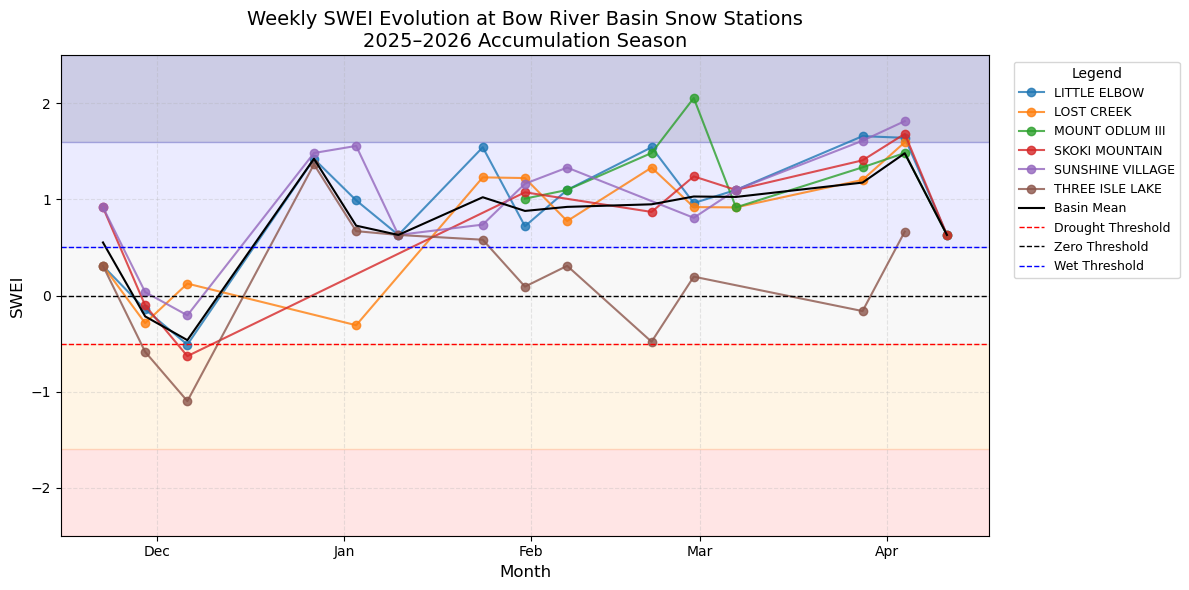

In [ ]:
# plot for season 2025
season_2025_weekly = Bow_weekly_swei[Bow_weekly_swei['Seasonal_Year'] == 2025].copy()

# remove SWEI = 0 rows
#season_2025_weekly = season_2025_weekly[season_2025_weekly['SWEI'] != 0].copy()

fig, ax = plt.subplots(figsize=(12,6))

# --- plot station lines (lighter) ---
for station_name, group in season_2025_weekly.groupby('station_name'):
    ax.plot(group['time'], group['SWEI'],
            marker='o', linewidth=1.5, alpha=0.8,
            label=station_name)

# --- optional basin mean ---
basin_mean = season_2025_weekly.groupby('time')['SWEI'].mean()
ax.plot(basin_mean.index, basin_mean.values,
        color='black', linewidth=1.5, linestyle='-',
        label='Basin Mean')

# --- drought/wet shading ---
ax.axhspan(-2.5, -1.6, color='red', alpha=0.1)
ax.axhspan(-1.6, -0.5, color='orange', alpha=0.1)
ax.axhspan(-0.5, 0.5, color='grey', alpha=0.05)
ax.axhspan(0.5, 1.6, color='blue', alpha=0.08)
ax.axhspan(1.6, 2.5, color='navy', alpha=0.2)

# --- key threshold lines ---
ax.axhline(-0.5, color='red', linestyle='--', linewidth=1, label='Drought Threshold')
ax.axhline(0, color='black', linestyle='--', linewidth=1, label='Zero Threshold')
ax.axhline(0.5, color='blue', linestyle='--', linewidth=1, label='Wet Threshold')
# --- labels ---
ax.set_title('Weekly SWEI Evolution at Bow River Basin Snow Stations\n2025–2026 Accumulation Season',
             fontsize=14)

ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('SWEI', fontsize=12)

# --- monthly ticks ---
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))

# --- limits ---
ax.set_ylim(-2.5,2.5)

# --- grid ---
ax.grid(True, linestyle='--', alpha=0.3)

# --- legend outside ---
ax.legend(title='Legend',
          bbox_to_anchor=(1.02,1),
          loc='upper left',
          fontsize=9)

plt.tight_layout()
save_path = config['output_plots'] / 'season_2025_weekly_swei.png'
plt.savefig(save_path, dpi=1000, bbox_inches='tight')
plt.show()

In [ ]:
Oldman_weekly_swei = compute_weekly_swei(
    df=final_oldman_df,
    window_weeks=1,      # 1-week SWEI
    week_freq="W-SAT",   # weekly ending Saturday
    weekly_agg="last"    # recommended for SWE
)

display(Oldman_weekly_swei.head())

,station_id,time,SWE_weekly,Seasonal_Year,season_week,SWE_1wk,Gringorten_p,SWEI,station_name
0,05AA809,1983-12-10,165.0,1983,11,165.0,0.500000,0.000000,GARDINER H.W.
1,05AA809,1984-02-04,371.0,1983,19,371.0,0.181303,-0.910410,GARDINER H.W.
2,05AA809,1984-03-03,465.0,1983,23,465.0,0.181303,-0.910410,GARDINER H.W.
3,05AA809,1984-03-31,498.0,1983,27,498.0,0.025316,-1.954578,GARDINER H.W.
4,05AA809,1984-05-05,605.0,1983,32,605.0,0.359551,-0.359660,GARDINER H.W.


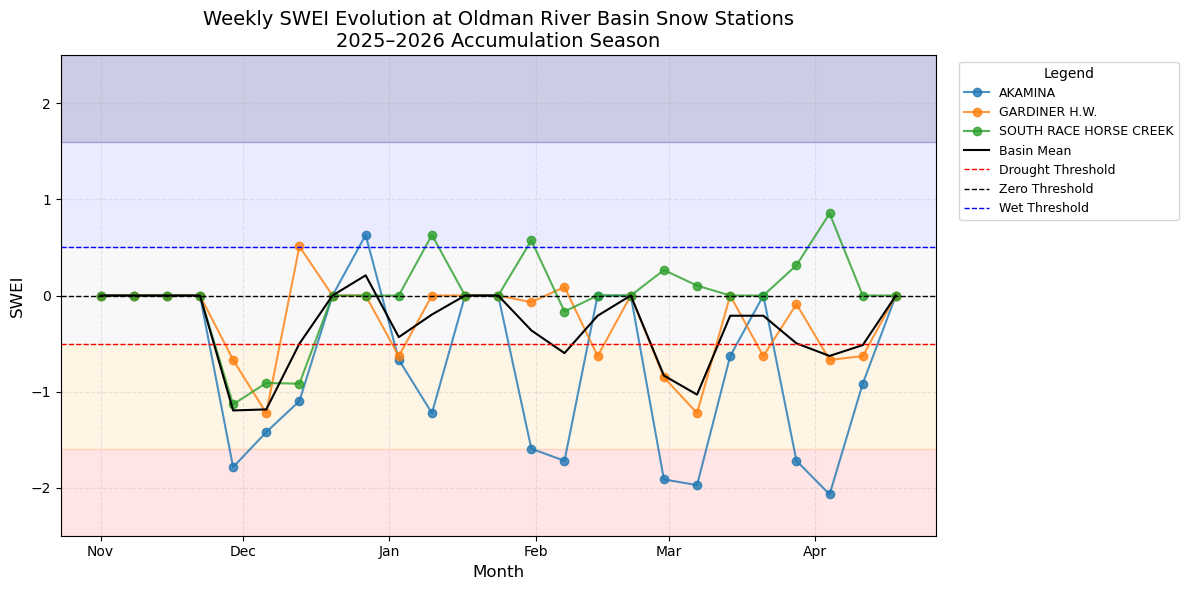

In [ ]:
# plot for season 2025
season_2025_weekly = Oldman_weekly_swei[Oldman_weekly_swei['Seasonal_Year'] == 2025].copy()

fig, ax = plt.subplots(figsize=(12,6))

# --- plot station lines (lighter) ---
for station_name, group in season_2025_weekly.groupby('station_name'):
    ax.plot(group['time'], group['SWEI'],
            marker='o', linewidth=1.5, alpha=0.8,
            label=station_name)

# --- optional basin mean ---
basin_mean = season_2025_weekly.groupby('time')['SWEI'].mean()
ax.plot(basin_mean.index, basin_mean.values,
        color='black', linewidth=1.5, linestyle='-',
        label='Basin Mean')

# --- drought/wet shading ---
ax.axhspan(-2.5, -1.6, color='red', alpha=0.1)
ax.axhspan(-1.6, -0.5, color='orange', alpha=0.1)
ax.axhspan(-0.5, 0.5, color='grey', alpha=0.05)
ax.axhspan(0.5, 1.6, color='blue', alpha=0.08)
ax.axhspan(1.6, 2.5, color='navy', alpha=0.2)

# --- key threshold lines ---
ax.axhline(-0.5, color='red', linestyle='--', linewidth=1, label='Drought Threshold')
ax.axhline(0, color='black', linestyle='--', linewidth=1, label='Zero Threshold')
ax.axhline(0.5, color='blue', linestyle='--', linewidth=1, label='Wet Threshold')
# --- labels ---
ax.set_title('Weekly SWEI Evolution at Oldman River Basin Snow Stations\n2025–2026 Accumulation Season',
             fontsize=14)

ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('SWEI', fontsize=12)

# --- monthly ticks ---
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))

# --- limits ---
ax.set_ylim(-2.5,2.5)

# --- grid ---
ax.grid(True, linestyle='--', alpha=0.3)

# --- legend outside ---
ax.legend(title='Legend',
          bbox_to_anchor=(1.02,1),
          loc='upper left',
          fontsize=9)

plt.tight_layout()
save_path = config['output_plots'] / 'season_2025_weekly_swei.png'
plt.savefig(save_path, dpi=1000, bbox_inches='tight')
plt.show()